# Étape 1 – Exploration du jeu de données d'images cérébrales

**Projet BrainScanAI** – Détection de tumeurs cérébrales  
Objectif : charger le dataset, explorer visuellement les images, vérifier résolution, canaux de couleur et structure des fichiers.

## 1. Imports

In [3]:
import sys
from pathlib import Path

# Ajoute la racine du projet au chemin Python pour pouvoir importer src/config.py
sys.path.append(str(Path("..").resolve()))

import numpy as np               
import pandas as pd              
import matplotlib.pyplot as plt  
from PIL import Image   # Lecture et inspection des fichiers image

## 2. Chemins du dataset

In [4]:
# Importation des chemins définis dans src/config.py
# Cela évite de réécrire les chemins dans chaque notebook
from src.config import DATA_DIR, CANCER_DIR, NORMAL_DIR, UNLABELED_DIR

# Affichage du nombre d'images dans chaque dossier pour vérifier que les données sont bien chargées
# glob('*') liste tous les fichiers du dossier, peu importe leur extension
print(f"Dossier données     : {DATA_DIR}")
print(f"Images cancer       : {len(list(CANCER_DIR.glob('*')))}")
print(f"Images normal       : {len(list(NORMAL_DIR.glob('*')))}")
print(f"Images sans label   : {len(list(UNLABELED_DIR.glob('*')))}")

Dossier données     : C:\Users\fkhellad\Formation_IA\Projet7_mission\data
Images cancer       : 50
Images normal       : 50
Images sans label   : 1406


## 3. Construction du DataFrame de métadonnées

In [5]:
records = []

# Parcours des images labellisées : on note le chemin, le label et le fait qu'elles soient labellisées
# Aucun pixel n'est chargé ici, seulement les chemins (opération légère)
for label, folder in [("cancer", CANCER_DIR), ("normal", NORMAL_DIR)]:
    for path in folder.glob("*.jpg"):
        records.append({"path": path, "label": label, "split": "labeled"})

# Parcours des images sans label : label vaut None car inconnu
for path in UNLABELED_DIR.glob("*.jpg"):
    records.append({"path": path, "label": None, "split": "unlabeled"})

# Conversion de la liste en DataFrame pandas pour faciliter les filtres et l'échantillonnage
df = pd.DataFrame(records)

# Affiche le nombre de lignes et de colonnes du DataFrame
print(df.shape)
df.head()

(1506, 3)


,path,label,split
0,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled
1,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled
2,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled
3,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled
4,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled


In [6]:
# Compte le nombre d'images par label (cancer, normal, et None pour les sans-label)
# dropna=False permet d'inclure les valeurs None dans le décompte
print("Distribution des labels :")
print(df["label"].value_counts(dropna=False))

Distribution des labels :
label
NaN       1406
cancer      50
normal      50
Name: count, dtype: int64


## 4. Vérification : résolution et canaux de couleur

In [ ]:
# On travaille sur un échantillon de 200 images maximum pour alléger le temps de traitement
# random_state=42 garantit que le même échantillon est tiré à chaque exécution
sample_paths = df.sample(min(200, len(df)), random_state=42)["path"].tolist()

sizes, modes, corrupted = [], [], []

for p in sample_paths:
    try:
        img = Image.open(p)
        img.verify()          # décompression complète pour détecter les fichiers tronqués ou invalides
        img = Image.open(p)   # réouverture obligatoire après verify() — verify() consomme le flux
        sizes.append(img.size)   # img.size retourne (largeur, hauteur) en pixels
        modes.append(img.mode)   # img.mode : "RGB" = couleur, "L" = niveaux de gris
    except Exception as e:
        # Toute exception PIL indique une image corrompue ou illisible
        corrupted.append({"path": str(p), "erreur": str(e)})
        print(f"  Image corrompue : {Path(p).name} — {e}")

# Affichage des résolutions trouvées, triées par fréquence
print("Résolutions uniques (largeur x hauteur) :")
print(pd.Series(sizes).value_counts())

# Affichage des modes couleur trouvés
print("\nModes couleur uniques :")
print(pd.Series(modes).value_counts())

# Bilan des anomalies détectées
if corrupted:
    print(f"\n⚠️  {len(corrupted)} image(s) corrompue(s) sur {len(sample_paths)} vérifiées :")
    print(pd.DataFrame(corrupted).to_string(index=False))
    # Suppression des images corrompues du DataFrame principal
    corrupted_paths = {c["path"] for c in corrupted}
    df = df[~df["path"].astype(str).isin(corrupted_paths)].reset_index(drop=True)
    print(f"Images supprimées du dataset — {len(df)} images restantes.")
else:
    print(f"\nAucune anomalie détectée sur les {len(sample_paths)} images vérifiées.")

Résolutions uniques (largeur x hauteur) :
(512, 512)    200
Name: count, dtype: int64

Modes couleur uniques :
RGB    200
Name: count, dtype: int64

Aucune anomalie détectée sur les 200 images vérifiées.


## 5. Visualisation d'exemples – images labellisées

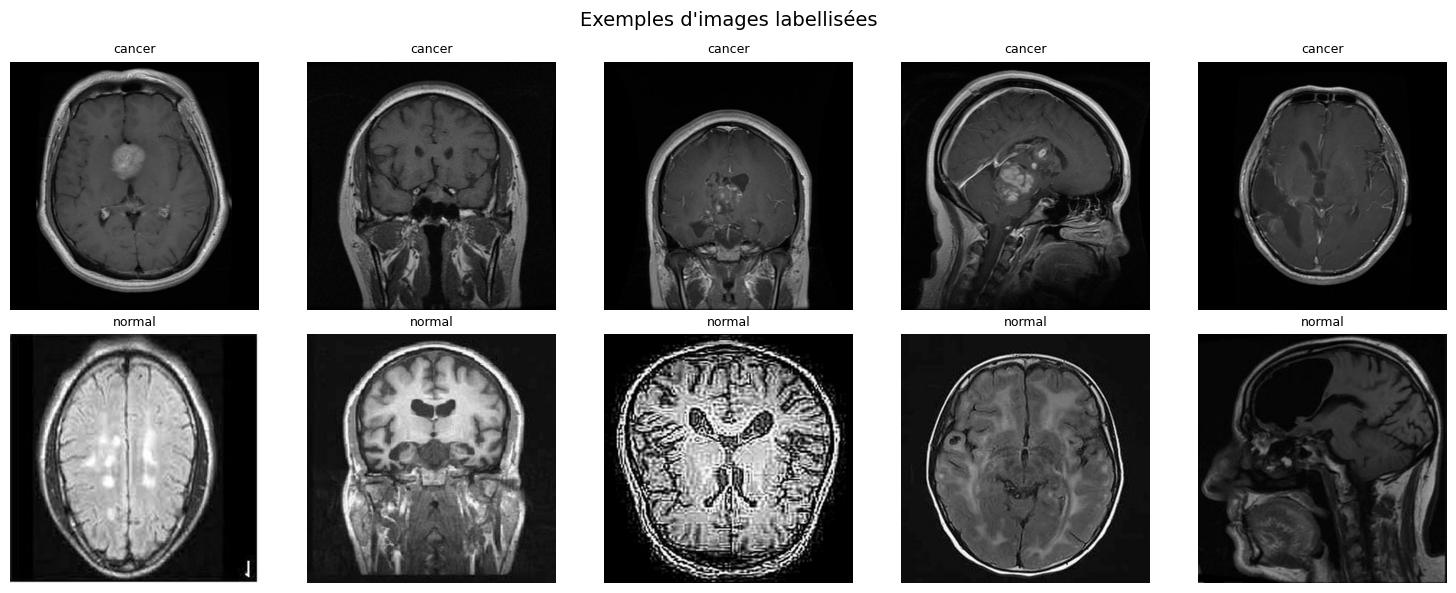

In [8]:
# Grille 2 lignes x 5 colonnes : une ligne par classe (cancer / normal), 5 exemples par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Exemples d'images labellisées", fontsize=14)

for i, label in enumerate(["cancer", "normal"]):
    # Tirage aléatoire de 5 images pour la classe courante
    sample = df[df["label"] == label].sample(5, random_state=42)
    for j, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row["path"])
        # cmap="gray" si l'image est en niveaux de gris, sinon matplotlib affiche les couleurs normalement
        axes[i, j].imshow(img, cmap="gray" if img.mode == "L" else None)
        axes[i, j].set_title(label, fontsize=9)
        axes[i, j].axis("off")  # Masque les axes pour un rendu plus propre

plt.tight_layout()
plt.show()

## 6. Visualisation d'exemples – images sans label

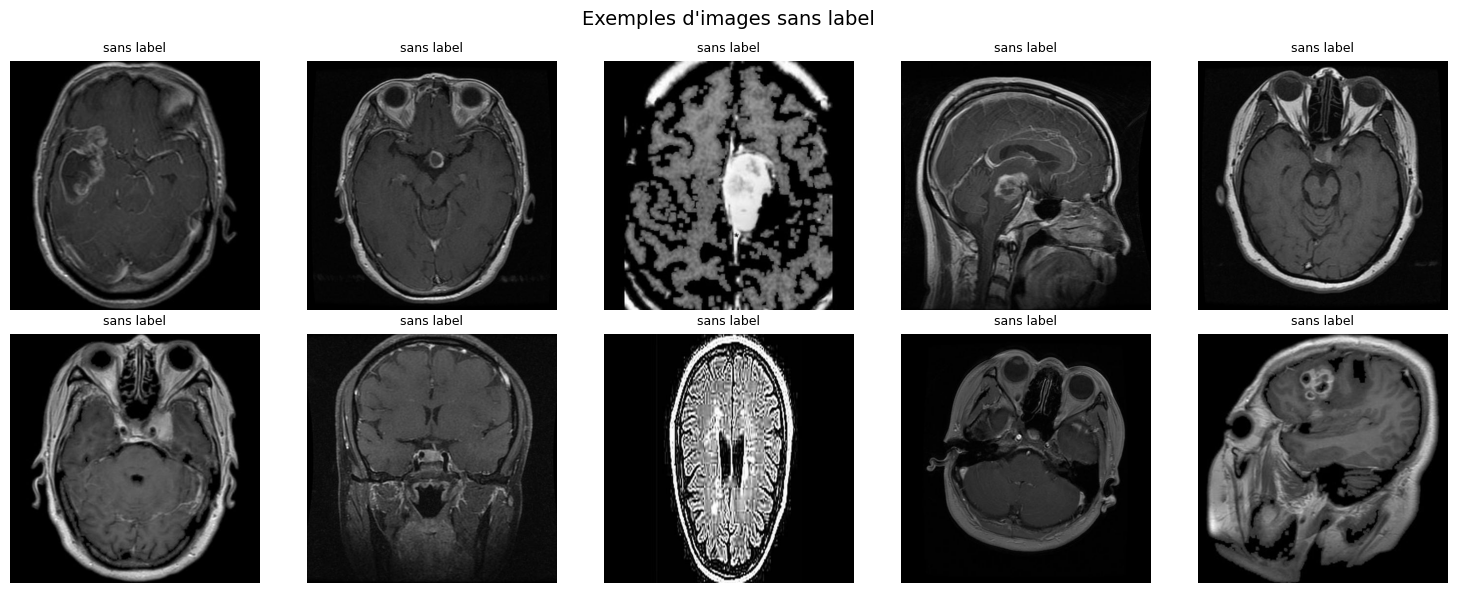

In [16]:
# Grille 2 lignes x 5 colonnes pour afficher 10 images sans label
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Exemples d'images sans label", fontsize=14)

# Tirage de 10 images parmi les images non labellisées
sample = df[df["split"] == "unlabeled"].sample(10, random_state=42)

# zip associe chaque case de la grille à une image de l'échantillon
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title("sans label", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Statistiques pixel sur un échantillon

In [17]:
pixel_means, pixel_stds = [], []

# On parcourt TOUTES les images (labellisées + sans label) pour calculer la moyenne et l'écart-type
# Ces valeurs serviront à normaliser les images avant de les passer au modèle
# Il est important d'utiliser tout le dataset car toutes les images seront utilisées à l'entraînement
for p in df["path"]:
    # convert("L") convertit l'image en niveaux de gris (1 seul canal)
    # On divise par 255 pour ramener les valeurs dans [0, 1]
    arr = np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0
    pixel_means.append(arr.mean())
    pixel_stds.append(arr.std())

# La moyenne et l'écart-type globaux résument la luminosité et le contraste du dataset
print(f"Nombre d'images analysées       : {len(pixel_means)}")
print(f"Moyenne pixel (niveaux de gris) : {np.mean(pixel_means):.4f}")
print(f"Écart-type pixel moyen          : {np.mean(pixel_stds):.4f}")

Nombre d'images analysées       : 1506
Moyenne pixel (niveaux de gris) : 0.2055
Écart-type pixel moyen          : 0.1919


In [9]:
from src.config import METADATA_PATH

# Sauvegarde le DataFrame en CSV pour être réutilisé par les notebooks suivants
# Cela évite de reconstruire la liste des images à chaque étape
df.to_csv(METADATA_PATH, index=False)
print(f"Métadonnées sauvegardées : {METADATA_PATH}")
print(f"  {len(df)} images — colonnes : {list(df.columns)}")

Métadonnées sauvegardées : C:\Users\fkhellad\Formation_IA\Projet7_mission\data\processed\metadata.csv
  1506 images — colonnes : ['path', 'label', 'split']


## 8. Analyse des biais — déséquilibre des classes

Les images labelisées (cancer/normal) sont parfaitement équilibrées (50/50). Cependant, les **weak labels générés par DBSCAN** à l'étape 3 peuvent introduire un déséquilibre sur les 1486 images d'entraînement.

On analyse ici ce déséquilibre potentiel et on détermine si un rééquilibrage est nécessaire.

> **Note** : ce fichier (`metadata_weak_labels_dbscan.csv`) est produit par le notebook 3. Exécuter le notebook 3 avant cette cellule.

Vrais labels — 80 images train labelisées :
label
cancer    40
normal    40
Name: count, dtype: int64
  → Ratio cancer : 50.0%  (parfaitement équilibré)

Weak labels DBSCAN — 1486 images train :
weak_label_dbscan
cancer    839
normal    647
Name: count, dtype: int64
  → Ratio cancer : 56.5% | Ratio normal : 43.5%


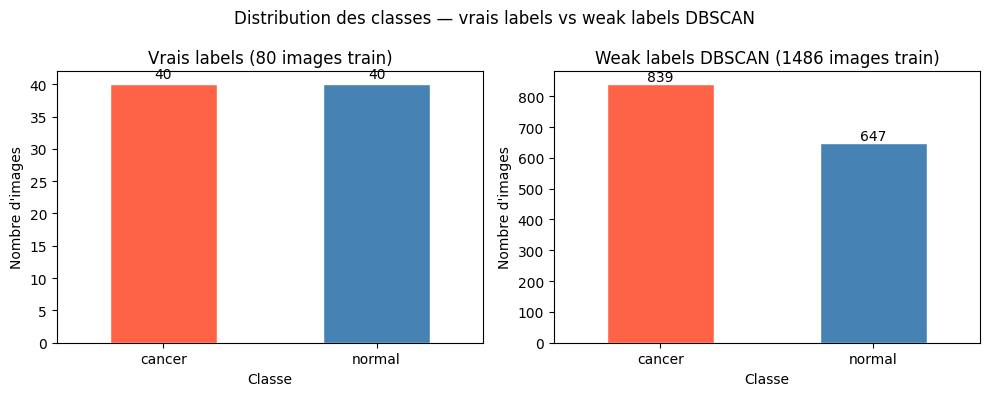


Déséquilibre DBSCAN : 6.5% d'écart par rapport à 50/50
✓  Déséquilibre modéré (≤ 10%) — les weak labels DBSCAN restent exploitables sans rééquilibrage forcé.
   L'augmentation de données (étape 2) sur les 80 images vraies compense partiellement ce biais.


In [10]:
from src.config import PROCESSED_DIR

meta_weak = pd.read_csv(PROCESSED_DIR / "metadata_weak_labels_dbscan.csv")
test_meta  = pd.read_csv(PROCESSED_DIR / "test_set.csv")

# Exclusion du test set pour n'analyser que les images d'entraînement
test_paths     = set(test_meta["path"].values)
meta_train     = meta_weak[~meta_weak["path"].isin(test_paths)].reset_index(drop=True)

# ── Vrais labels : 80 images fortement labelisées ────────────────────────────
labels_forts = meta_train[meta_train["label"].notna()]["label"]
print("Vrais labels — 80 images train labelisées :")
print(labels_forts.value_counts())
print(f"  → Ratio cancer : {labels_forts.value_counts(normalize=True)['cancer']:.1%}  (parfaitement équilibré)")

# ── Weak labels DBSCAN : 1486 images train ───────────────────────────────────
dist_weak = meta_train["weak_label_dbscan"].value_counts()
ratio_weak = meta_train["weak_label_dbscan"].value_counts(normalize=True)

print(f"\nWeak labels DBSCAN — {len(meta_train)} images train :")
print(dist_weak)
print(f"  → Ratio cancer : {ratio_weak['cancer']:.1%} | Ratio normal : {ratio_weak['normal']:.1%}")

# ── Visualisation comparative ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Distribution des classes — vrais labels vs weak labels DBSCAN", fontsize=12)

# Vrais labels (80 images)
labels_forts.value_counts().plot(kind="bar", ax=axes[0], color=["tomato", "steelblue"], edgecolor="white")
axes[0].set_title("Vrais labels (80 images train)")
axes[0].set_xlabel("Classe"); axes[0].set_ylabel("Nombre d'images")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

# Weak labels DBSCAN (1486 images)
dist_weak.plot(kind="bar", ax=axes[1], color=["tomato", "steelblue"], edgecolor="white")
axes[1].set_title("Weak labels DBSCAN (1486 images train)")
axes[1].set_xlabel("Classe"); axes[1].set_ylabel("Nombre d'images")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# ── Bilan et décision de rééquilibrage ───────────────────────────────────────
desequilibre = abs(ratio_weak["cancer"] - 0.5)
print(f"\nDéséquilibre DBSCAN : {desequilibre:.1%} d'écart par rapport à 50/50")

if desequilibre > 0.10:
    print("⚠️  Déséquilibre significatif (> 10%) — rééquilibrage recommandé (oversampling ou class_weight).")
else:
    print("✓  Déséquilibre modéré (≤ 10%) — les weak labels DBSCAN restent exploitables sans rééquilibrage forcé.")
    print("   L'augmentation de données (étape 2) sur les 80 images vraies compense partiellement ce biais.")

## 9. Observations et conclusions

- **Nombre d'images labellisées** : 100 (50 cancer / 50 normal) — dataset très limité, justifie l'approche semi-supervisée
- **Nombre d'images sans label** : 1406 — c'est la majorité du dataset, elles seront exploitées en semi-supervisé
- **Résolutions observées** : toutes les images sont en (512 x 512) pixels — aucun redimensionnement nécessaire pour le preprocessing initial
- **Mode couleur** : RGB, alors que les images sont visuellement en niveaux de gris (les 3 canaux R, G, B contiennent les mêmes valeurs) — conversion en `"L"` obligatoire lors du preprocessing
- **Luminosité moyenne** : 0.2055 sur [0, 1] — images globalement sombres, ce qui est typique des IRM cérébrales
- **Écart-type pixel moyen** : 0.1919 — faible contraste global, le fond noir domine largement
- **Homogénéité** : les valeurs calculées sur 200 images (0.2099 / 0.1917) et sur les 1506 images complètes (0.2055 / 0.1919) sont quasi identiques — le dataset est homogène, sans sous-groupe visuellement très différent
- **Qualité / anomalies** : aucune image corrompue détectée, structure de fichiers cohérente
- **Points d'attention pour le preprocessing** :
  - Forcer `.convert("L")` à chaque chargement d'image pour passer de RGB à niveaux de gris
  - Normaliser les pixels avec la moyenne (0.2055) et l'écart-type (0.1919) calculés sur l'ensemble du dataset
  - Les images étant toutes en 512x512, un redimensionnement vers 224x224 sera nécessaire pour les modèles pré-entraînés (ResNet, etc.)